In [5]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
riyagarg0314_discord_github_ecosystem_2026_path = kagglehub.dataset_download('riyagarg0314/discord-github-ecosystem-2026')

print('Data source import complete.')


Using Colab cache for faster access to the 'discord-github-ecosystem-2026' dataset.
Data source import complete.


In [6]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/discord-github-ecosystem-2026/discord_ecosystem_2026.csv


 # Discord GitHub Ecosystem 2026 — EDA
Comparing Discord's 88 official repos against 1,647 community-built bots, libraries, and integrations.

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import os

df = pd.read_csv(os.path.join(riyagarg0314_discord_github_ecosystem_2026_path, 'discord_ecosystem_2026.csv'))
df.shape

(1735, 26)

In [17]:
average_stars_by_owner_type = df.groupby('owner_type')['stars'].mean()
display(average_stars_by_owner_type)

,stars
owner_type,
Organization,684.891960
User,159.153328


In [25]:
archived_vs_active = df.groupby(['owner_type', 'archived']).size().unstack(fill_value=0)
archived_vs_active.columns = ['Active', 'Archived'] # Rename columns for clarity
display(archived_vs_active)

,Active,Archived
owner_type,,
Organization,320,78
User,1118,219


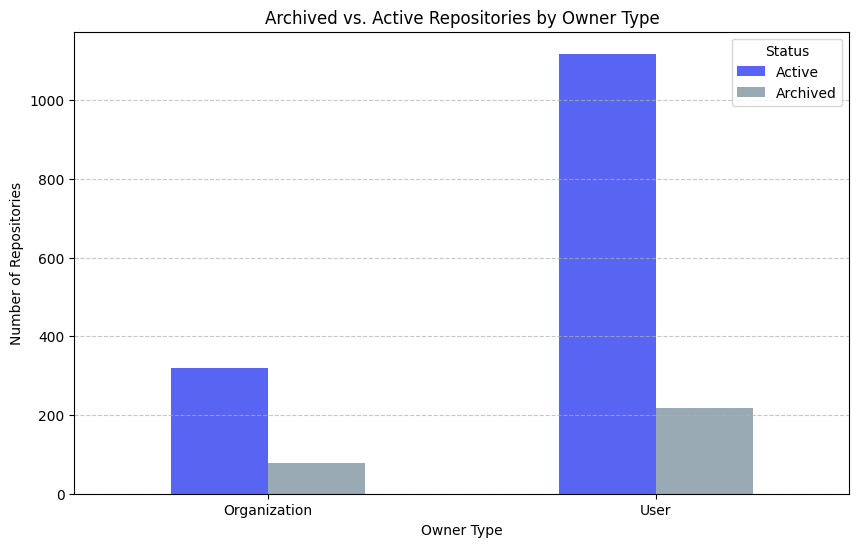

In [26]:
archived_vs_active.plot(kind='bar', figsize=(10, 6), color=['#5865F2', '#99AAB5'])
plt.title('Archived vs. Active Repositories by Owner Type')
plt.xlabel('Owner Type')
plt.ylabel('Number of Repositories')
plt.xticks(rotation=0)
plt.legend(title='Status')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [28]:
print("Top 5 repositories by size (KB) for each owner_type:")
top_repos_by_size = df.groupby('owner_type').apply(lambda x: x.nlargest(5, 'size_kb'), include_groups=False).reset_index()
display(top_repos_by_size[['owner_type', 'full_name', 'size_kb']])

Top 5 repositories by size (KB) for each owner_type:


,owner_type,full_name,size_kb
0,Organization,discord/lilliput,531349
1,Organization,kordlib/kord,444518
2,Organization,serenity-rs/poise,415830
3,Organization,ihrz/ihrz,357475
4,Organization,poketwo/poketwo,356846
5,User,Phantom-101/project-ip-2,2932723
6,User,Oradimi/KanColle-English-Patch-KCCP,2595074
7,User,jamcalli/Pulsarr,606397
8,User,thomas-xin/Miza,583298
9,User,Spiderjockey02/Discord-Bot,506056


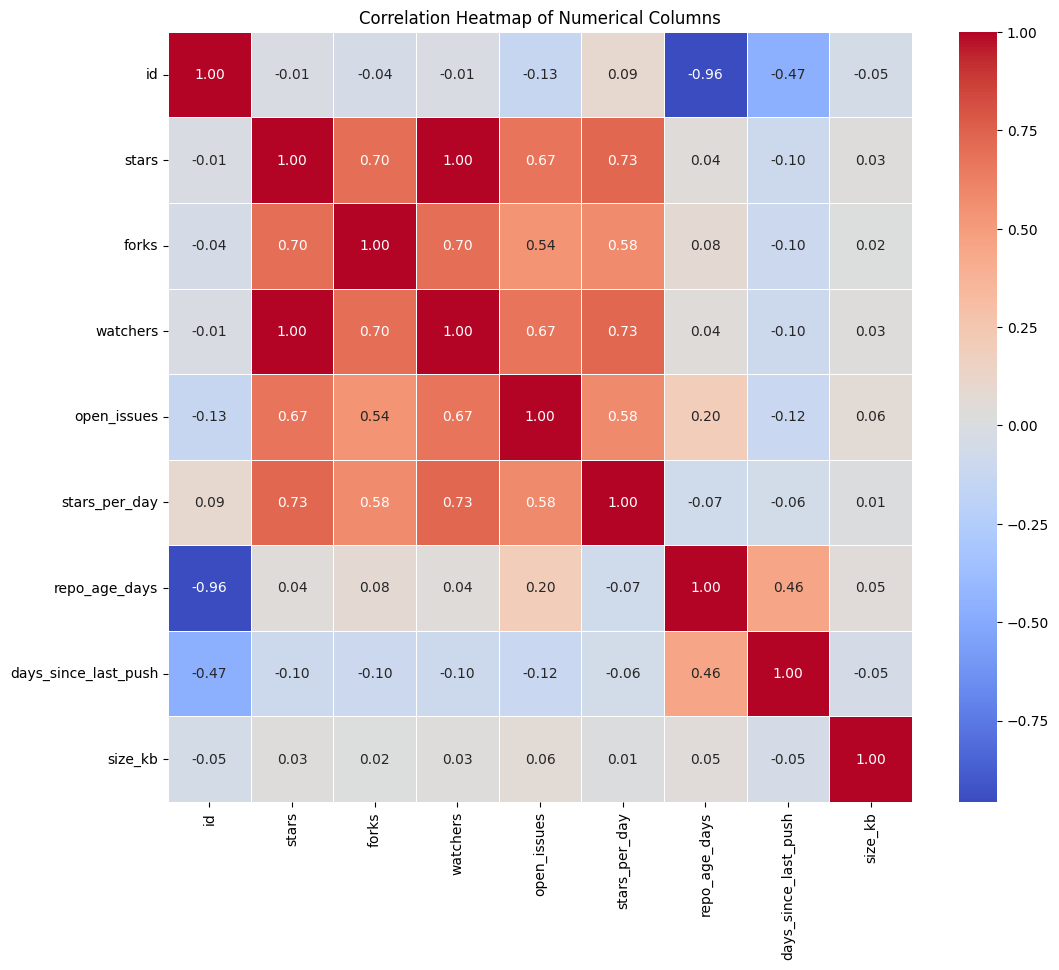

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns for correlation calculation
numerical_df = df.select_dtypes(include=['number'])

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

# Create a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Numerical Columns')
plt.show()

In [30]:
print('Repositories with the highest number of stars:')
display(df.nlargest(10, 'stars')[['full_name', 'stars', 'owner_type', 'language']])

Repositories with the highest number of stars:


,full_name,stars,owner_type,language
0,HKUDS/nanobot,46967,Organization,Python
1,LAION-AI/Open-Assistant,37408,Organization,Python
2,discordjs/discord.js,26783,Organization,TypeScript
3,langbot-app/LangBot,17404,Organization,Python
4,Rapptz/discord.py,16139,User,Python
5,discord/discord-api-docs,6459,Organization,MDX
6,codebymitch/TitanBot,6404,User,JavaScript
7,bwmarrin/discordgo,5971,User,Go
8,jagrosh/MusicBot,5753,User,Java
9,ayn2op/discordo,5730,User,Go


In [33]:
print('Top repositories grouped by primary language:')

top_repos_by_language = df.groupby('language').apply(
    lambda x: x.nlargest(3, 'stars').assign(language=x.name)[['language', 'full_name', 'stars', 'owner_type']],
    include_groups=False
).reset_index(drop=True)

display(top_repos_by_language)

Top repositories grouped by primary language:


,language,full_name,stars,owner_type
0,AMPL,Isenreik/IR-HoI4-Sanguinem-et-Lacrimas,2,Organization
1,Batchfile,uhAlexz/Limed,3,User
2,Blade,thatsmybis/thatsmybis,32,Organization
3,C,Cogmasters/concord,643,Organization
4,C,0e4ef622/wine-discord-ipc-bridge,460,User
...,...,...,...,...
99,TypeScript,vercel/chat,2286,Organization
100,Valve Data Format,Jotunn/kbnhud,40,User
101,Vue,markterence/discord-quest-completer,801,User
102,Vue,discordjs/website,186,Organization


In [20]:
median_stars_by_owner_type = df.groupby('owner_type')['stars'].median()
display(median_stars_by_owner_type)

,stars
owner_type,
Organization,89.0
User,34.0


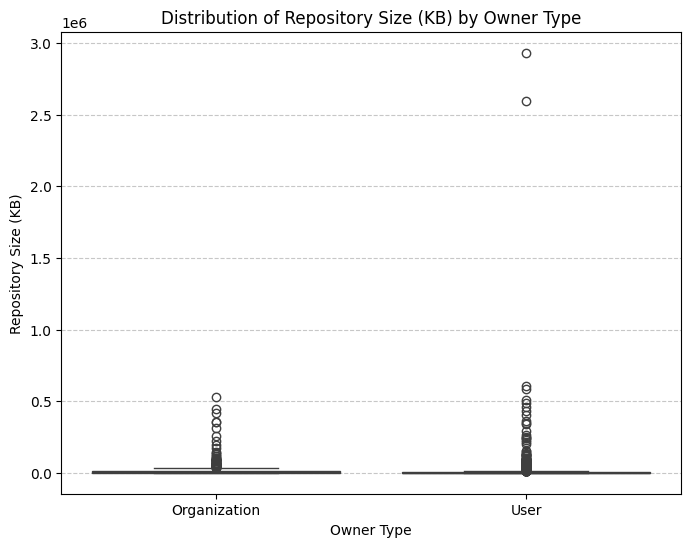

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(x='owner_type', y='size_kb', data=df)
plt.title('Distribution of Repository Size (KB) by Owner Type')
plt.xlabel('Owner Type')
plt.ylabel('Repository Size (KB)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

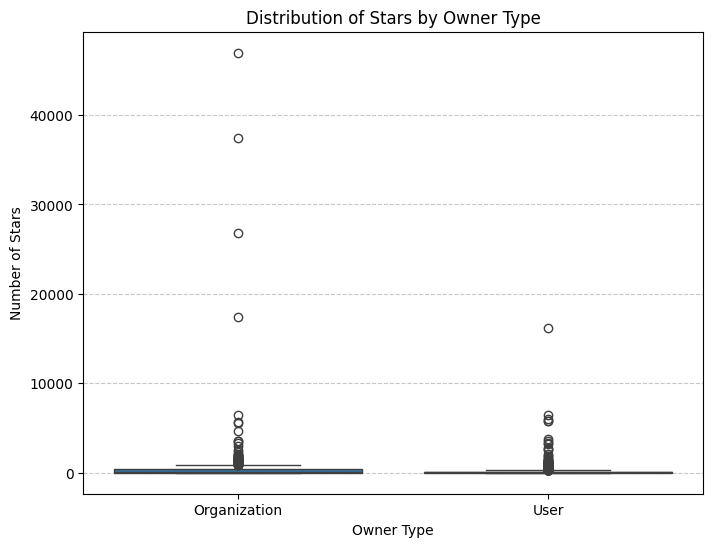

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(x='owner_type', y='stars', data=df)
plt.title('Distribution of Stars by Owner Type')
plt.xlabel('Owner Type')
plt.ylabel('Number of Stars')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [19]:
owner_type_counts = df['owner_type'].value_counts()
display(owner_type_counts)

,count
owner_type,
User,1337
Organization,398


/tmp/ipykernel_3732/304443738.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=owner_type_counts.index, y=owner_type_counts.values, palette='viridis')


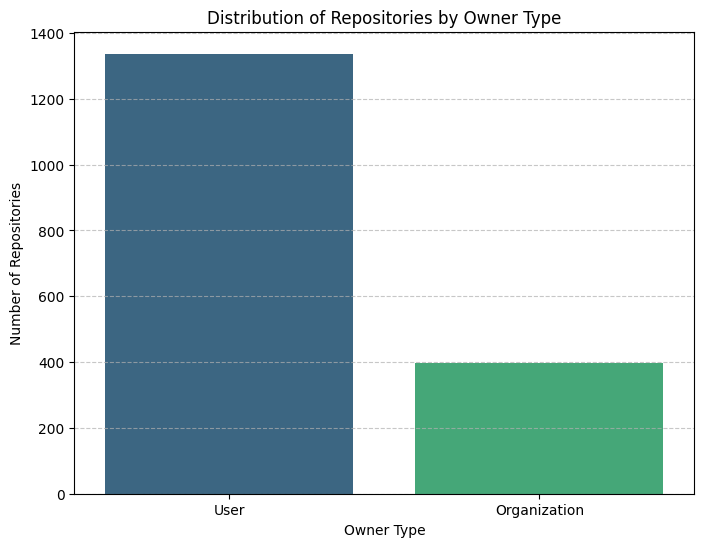

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.barplot(x=owner_type_counts.index, y=owner_type_counts.values, palette='viridis')
plt.title('Distribution of Repositories by Owner Type')
plt.xlabel('Owner Type')
plt.ylabel('Number of Repositories')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [36]:
average_size_by_owner_type = df.groupby('owner_type')['size_kb'].mean()
display(average_size_by_owner_type)

,size_kb
owner_type,
Organization,21416.643216
User,15895.434555


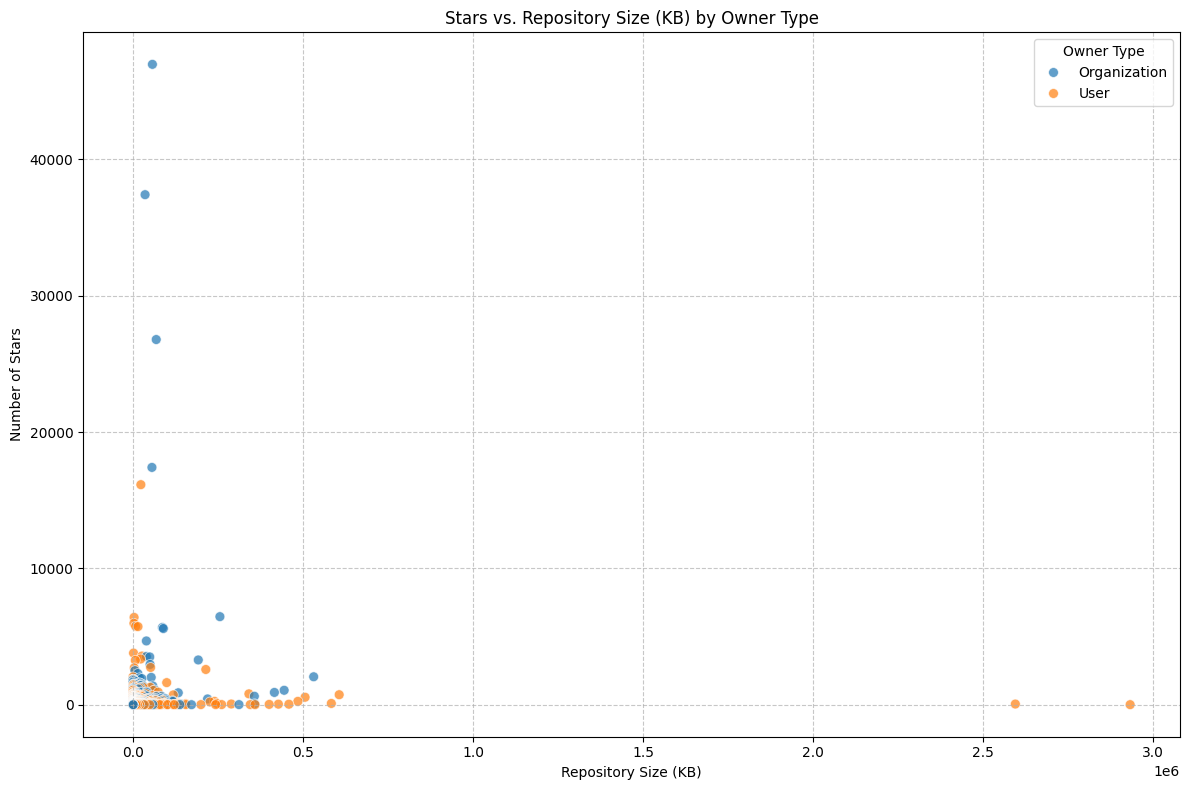

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.scatterplot(x='size_kb', y='stars', hue='owner_type', data=df, alpha=0.7, s=50)
plt.title('Stars vs. Repository Size (KB) by Owner Type')
plt.xlabel('Repository Size (KB)')
plt.ylabel('Number of Stars')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Owner Type')
plt.tight_layout()
plt.show()

In [38]:
correlation_stars_size = df['stars'].corr(df['size_kb'])
print(f"Correlation between stars and repository size (KB): {correlation_stars_size:.2f}")

Correlation between stars and repository size (KB): 0.03


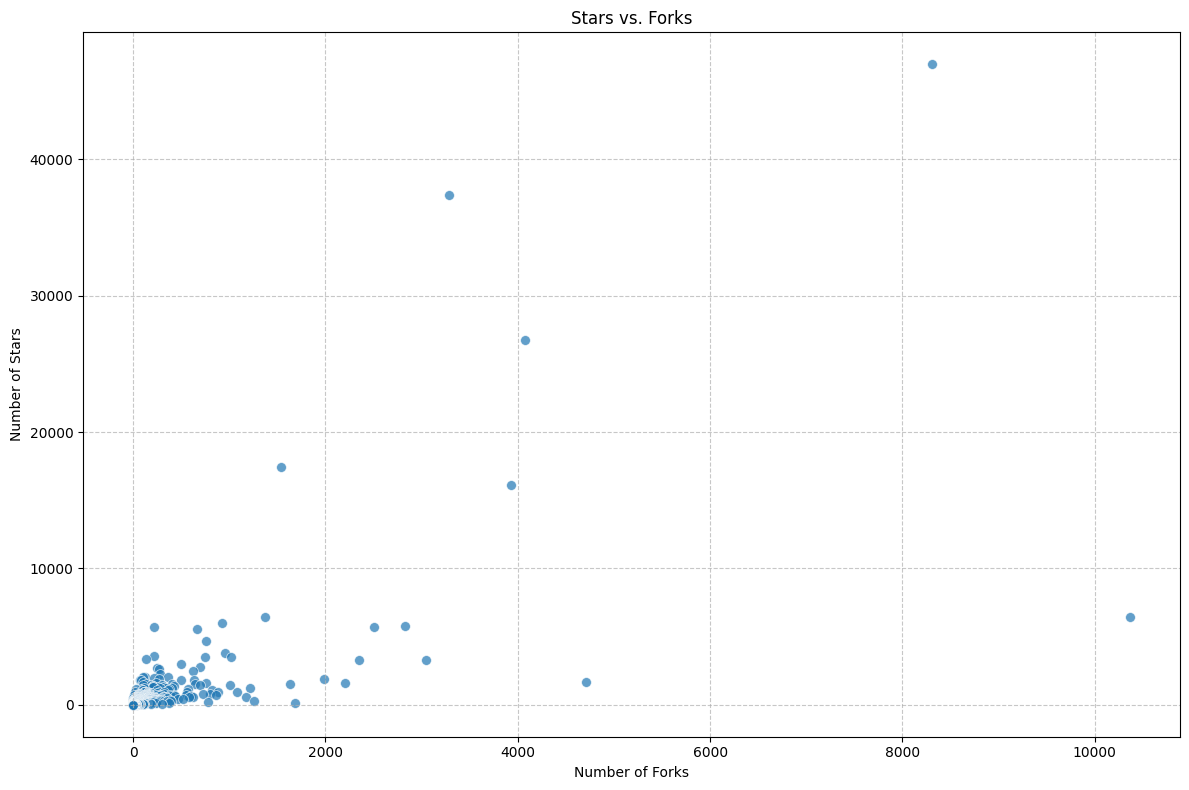

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.scatterplot(x='forks', y='stars', data=df, alpha=0.7, s=50)
plt.title('Stars vs. Forks')
plt.xlabel('Number of Forks')
plt.ylabel('Number of Stars')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [40]:
correlation_stars_forks = df['stars'].corr(df['forks'])
print(f"Correlation between stars and forks: {correlation_stars_forks:.2f}")

Correlation between stars and forks: 0.70


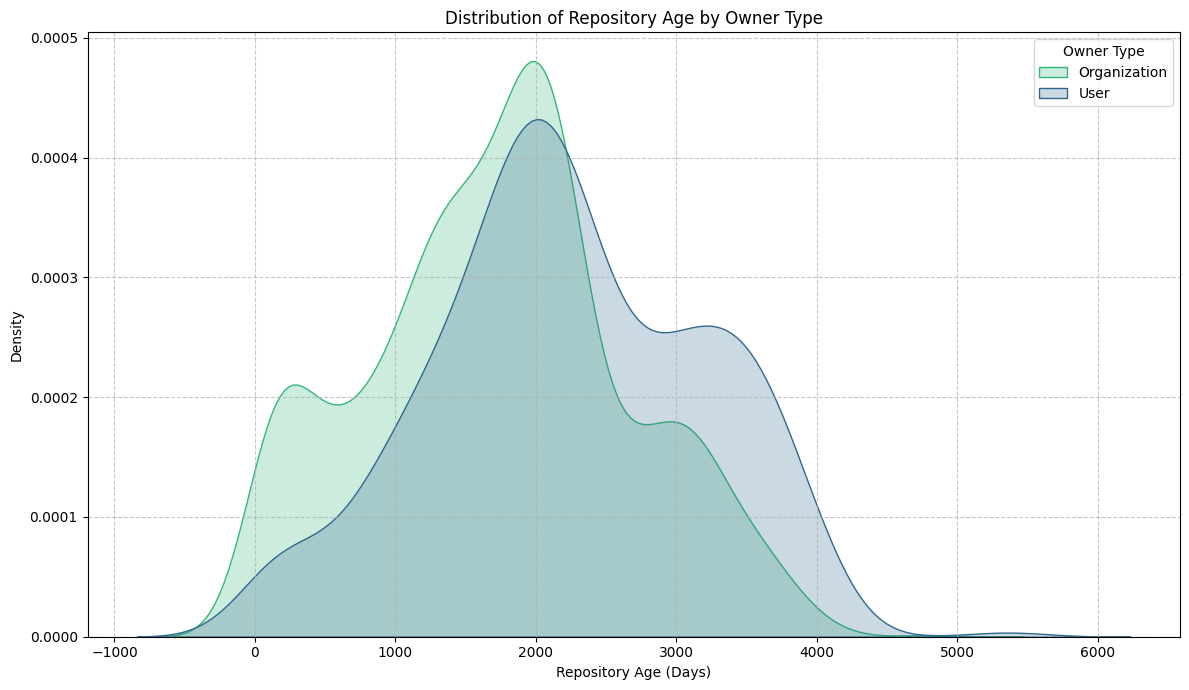

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.kdeplot(data=df, x='repo_age_days', hue='owner_type', fill=True, common_norm=False, palette='viridis')
plt.title('Distribution of Repository Age by Owner Type')
plt.xlabel('Repository Age (Days)')
plt.ylabel('Density')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Owner Type', labels=['Organization', 'User'])
plt.tight_layout()
plt.show()

In [14]:
correlation = df['repo_age_days'].corr(df['stars'])
print(f"Correlation between repo_age_days and stars: {correlation:.2f}")

Correlation between repo_age_days and stars: 0.04


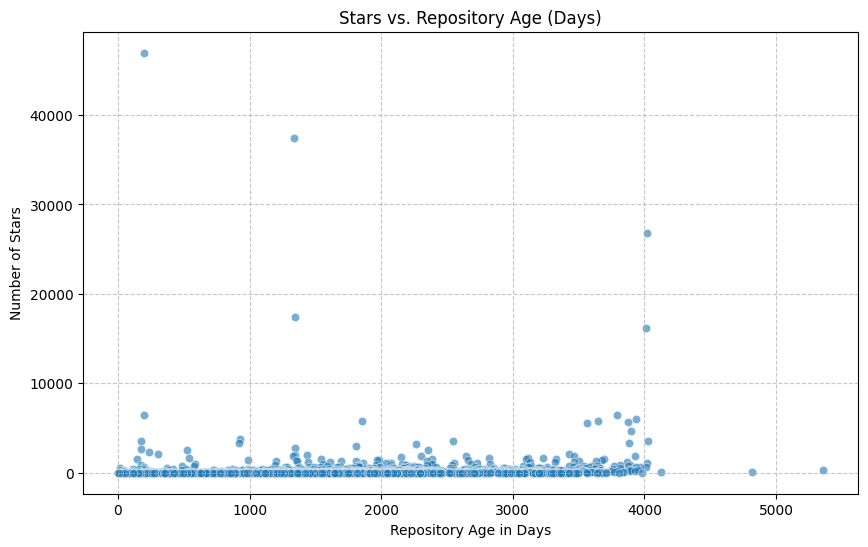

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='repo_age_days', y='stars', data=df, alpha=0.6)
plt.title('Stars vs. Repository Age (Days)')
plt.xlabel('Repository Age in Days')
plt.ylabel('Number of Stars')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [12]:
display(df.describe())

,id,stars,forks,watchers,open_issues,stars_per_day,repo_age_days,days_since_last_push,size_kb
count,1.735000e+03,1735.000000,1735.000000,1735.000000,1735.000000,1735.000000,1735.000000,1735.000000,1.735000e+03
mean,4.647442e+08,279.755043,82.212104,279.755043,10.277810,0.379833,1847.689337,824.838617,1.716197e+04
std,3.182297e+08,1751.503986,421.313893,1751.503986,31.468793,6.021780,958.363676,781.833640,1.058258e+05
min,2.977472e+06,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000,1.000000e+00
25%,2.378167e+08,8.000000,2.000000,8.000000,0.000000,0.010000,1207.000000,110.000000,9.050000e+01
50%,3.787573e+08,43.000000,10.000000,43.000000,2.000000,0.030000,1880.000000,686.000000,8.300000e+02
75%,6.321391e+08,163.000000,41.000000,163.000000,8.000000,0.100000,2384.000000,1341.000000,5.551500e+03
max,1.329647e+09,46967.000000,10367.000000,46967.000000,711.000000,242.100000,5357.000000,3709.000000,2.932723e+06


In [13]:
avg_official_repo_age = official['repo_age_days'].mean()
avg_community_repo_age = community['repo_age_days'].mean()

print(f"Average repository age for official repos: {avg_official_repo_age:.2f} days")
print(f"Average repository age for community repos: {avg_community_repo_age:.2f} days")

Average repository age for official repos: 2248.20 days
Average repository age for community repos: 1826.29 days


In [15]:
avg_official_stars = official['stars'].mean()
avg_community_stars = community['stars'].mean()

print(f"Average stars for official repos: {avg_official_stars:.2f}")
print(f"Average stars for community repos: {avg_community_stars:.2f}")

Average stars for official repos: 329.02
Average stars for community repos: 277.12


## Official vs. community: who actually built the ecosystem?

Official repos: 88, total stars: 28,954
Community repos: 1647, total stars: 456,421


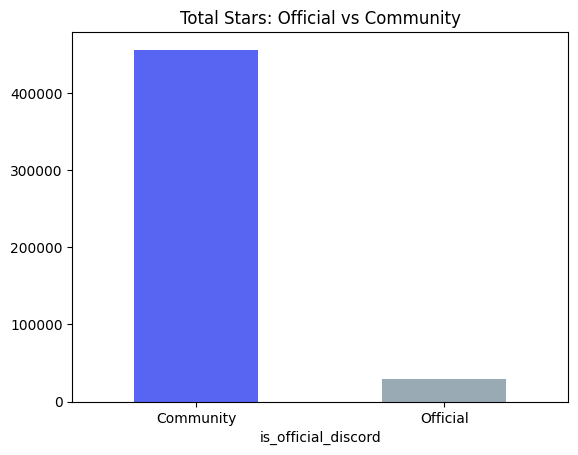

In [8]:
official = df[df['is_official_discord']]
community = df[~df['is_official_discord']]

print(f"Official repos: {len(official)}, total stars: {official['stars'].sum():,}")
print(f"Community repos: {len(community)}, total stars: {community['stars'].sum():,}")

df.groupby('is_official_discord')['stars'].sum().plot(kind='bar', color=['#5865F2','#99AAB5'])
plt.title('Total Stars: Official vs Community')
plt.xticks([0,1], ['Community','Official'], rotation=0)
plt.show()

## Top 15 repos overall

In [9]:
df.nlargest(15, 'stars')[['full_name','is_official_discord','stars','language']]

,full_name,is_official_discord,stars,language
0,HKUDS/nanobot,False,46967,Python
1,LAION-AI/Open-Assistant,False,37408,Python
2,discordjs/discord.js,False,26783,TypeScript
3,langbot-app/LangBot,False,17404,Python
4,Rapptz/discord.py,False,16139,Python
5,discord/discord-api-docs,True,6459,MDX
6,codebymitch/TitanBot,False,6404,JavaScript
7,bwmarrin/discordgo,False,5971,Go
8,jagrosh/MusicBot,False,5753,Java
9,ayn2op/discordo,False,5730,Go


## Which languages dominate Discord bot development?

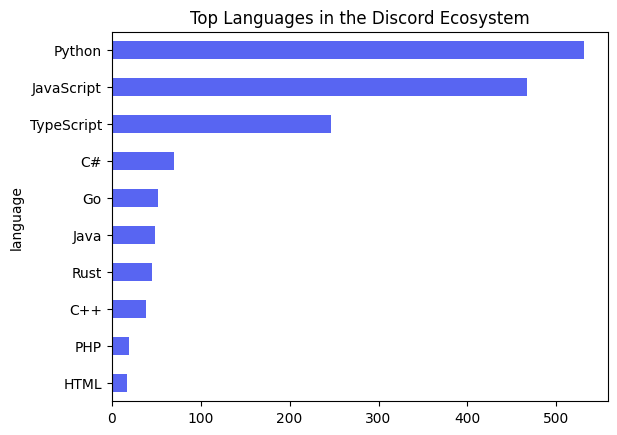

In [10]:
df['language'].value_counts().head(10).plot(kind='barh', color='#5865F2')
plt.title('Top Languages in the Discord Ecosystem')
plt.gca().invert_yaxis()
plt.show()

/tmp/ipykernel_3732/2347804179.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=language_counts.values, y=language_counts.index, palette='viridis')


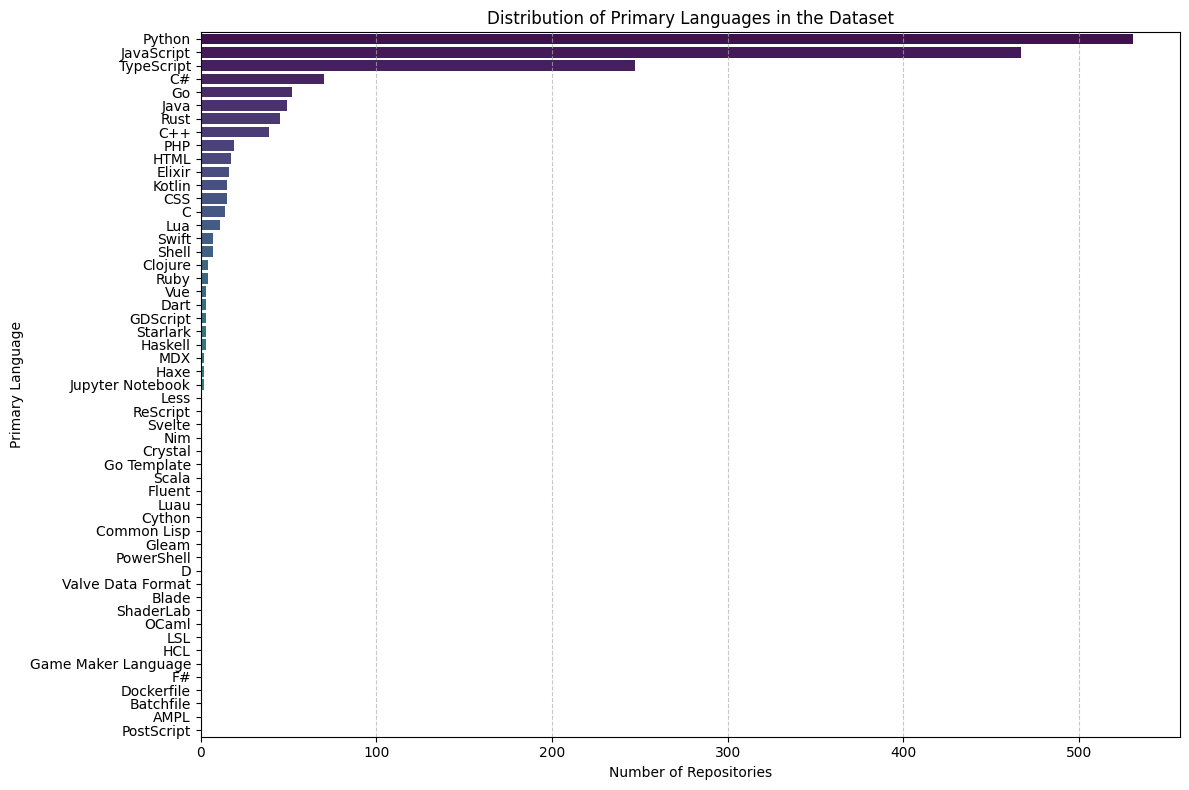

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

language_counts = df['language'].value_counts()

plt.figure(figsize=(12, 8))
sns.barplot(x=language_counts.values, y=language_counts.index, palette='viridis')
plt.title('Distribution of Primary Languages in the Dataset')
plt.xlabel('Number of Repositories')
plt.ylabel('Primary Language')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## discord.js vs discord.py vs discordgo — community library adoption

In [11]:
libs = df[df['name'].isin(['discord.js','discord.py','discordgo','discordo','discordrb'])]
libs[['name','stars','forks','language']].sort_values('stars', ascending=False)

,name,stars,forks,language
2,discord.js,26783,4074,TypeScript
4,discord.py,16139,3927,Python
7,discordgo,5971,926,Go
9,discordo,5730,222,Go
111,discordrb,692,149,Ruby
